In [3]:
%load_ext autoreload
%autoreload 2

In [5]:
from IPython.display import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fourier_model import FourierModel
from preprocess import preprocess_data, generate_training_data
from feature_importance import ShapImportance, plot_partial_dependence

In [6]:
# toy dataset

data = pd.read_csv('./data/test.tsv', sep='\t')
data['noise'] = np.random.normal(0, 1, size=len(data))
data.to_csv('./data/test_with_noise.tsv', sep='\t', index=False)

In [7]:
data.columns

Index(['identifier', 'sex', 'age', 'time', 'CRP_bl', 'FERR_bl', 'IRON_bl',
       'TRANSFS_bl', 'UIBC_bl', 'TRANSF_bl', 'HEP_bl', 'WBC_10_9_L_bl',
       'RBC_10_12_L_bl', 'HGB_g_dL_bl', 'HCT_PCT_bl', 'MCV_fL_bl', 'MCH_pg_bl',
       'MCHC_g_dL_bl', 'PLT_10_9_L_bl', 'RDW_SD_fL_bl', 'RDW_CV_PCT_bl',
       'PDW_fL_bl', 'MPV_fL_bl', 'P_LCR_PCT_bl', 'PCT_PCT_bl',
       'NEUT_10_9_L_bl', 'LYMPH_10_9_L_bl', 'MONO_10_9_L_bl', 'EO_10_9_L_bl',
       'BASO_10_9_L_bl', 'NEUT_PCT_bl', 'LYMPH_PCT_bl', 'MONO_PCT_bl',
       'EO_PCT_bl', 'BASO_PCT_bl', 'IG_10_9_L_bl', 'IG_PCT_bl', 'RET_PCT_bl',
       'RET_10_6_uL_bl', 'IRF_PCT_bl', 'LFR_PCT_bl', 'MFR_PCT_bl',
       'HFR_PCT_bl', 'RET_He_pg_bl', 'IPF_bl', 'PLT_I_10_9_L_bl',
       'MicroR_PCT_bl', 'MacroR_PCT_bl', 'TNC_10_9_L_bl', 'WBC_N_10_9_L_bl',
       'TNC_N_10_9_L_bl', 'BA_N_10_9_L_bl', 'BA_N_PCT_bl', 'WBC_D_10_9_L_bl',
       'TNC_D_10_9_L_bl', 'NEUTx_10_9_L_bl', 'NEUTx_PCT_bl', 'LYMP_10_9_L_bl',
       'LYMP_PCT_bl', 'BA_D_10_9_L_bl', 'BA

In [8]:
# format data

response = 'BASO_PCT_bl'
covariates = ['sex', 'age', 'noise']
X, y, time_data = preprocess_data(data, covariates, response, scale=False)

# generate training data

X_train_features, X_test_features, X_train_time, X_test_time, y_train, y_test = generate_training_data(X, y)


In [9]:
X_train_features.shape[1]

3

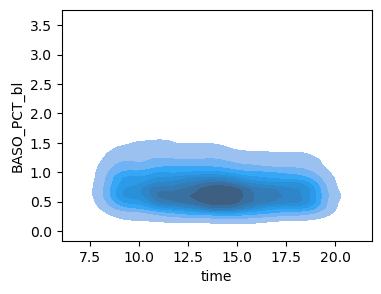

In [10]:
# plot data as a KDE density plot

import seaborn as sns

plt.figure(figsize=(4, 3))
sns.kdeplot(
    data=data, x="time", y=response, fill=True,
)
plt.show()

In [11]:
model = FourierModel(X_train_features.shape[1], 24.0, harmonics=[2.,3.,4.,6.], learning_rate=0.005)


Compiling the model...


In [12]:
model.train(X_train_features, X_train_time, y_train, X_test_features, X_test_time, y_test)

Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 91.4056 - mean_absolute_error: 4.5582 - val_loss: 0.2145 - val_mean_absolute_error: 0.3547
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.8744 - mean_absolute_error: 0.7493 - val_loss: 0.1335 - val_mean_absolute_error: 0.2906
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6723 - mean_absolute_error: 0.4431 - val_loss: 0.1133 - val_mean_absolute_error: 0.2649
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2780 - mean_absolute_error: 0.3338 - val_loss: 0.1130 - val_mean_absolute_error: 0.2638
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1836 - mean_absolute_error: 0.3019 - val_loss: 0.1102 - val_mean_absolute_error: 0.2577
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1555 - mean_absolute_error: 0.2867 - val_loss: 0.1096 - val_mean_absolute_error: 0.2542
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1362 - mean_absolute_error: 0.2729 - 

[0.09982118010520935, 0.23980627954006195]

In [13]:
model.save('./tmp/fourier_model.noise.keras')

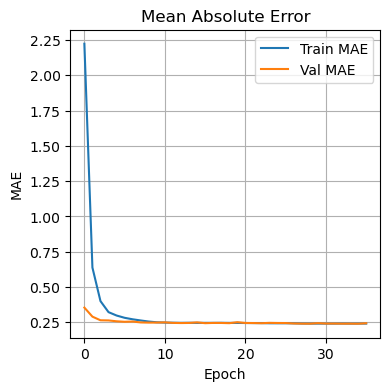

In [14]:
model.plot_learning('./tmp/learning_curve.png')

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


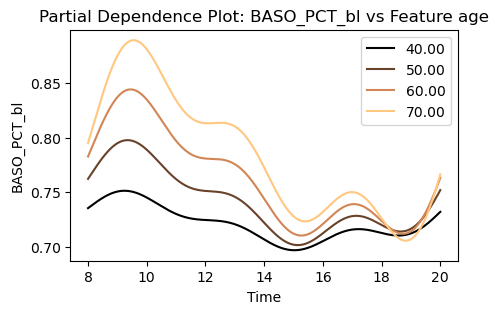

In [15]:
# age partial dependence

plot_partial_dependence(model.model, 1, [40, 50, 60, 70], ['sex', 'age', 'noise'], X, response, './tmp/partial_dependence_age.png')

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


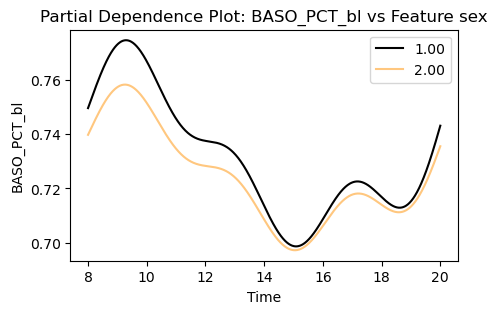

In [16]:
# sex partial dependence

plot_partial_dependence(model.model, 0, [1, 2], ['sex', 'age', 'noise'], X, response, './tmp/partial_dependence_sex.png')

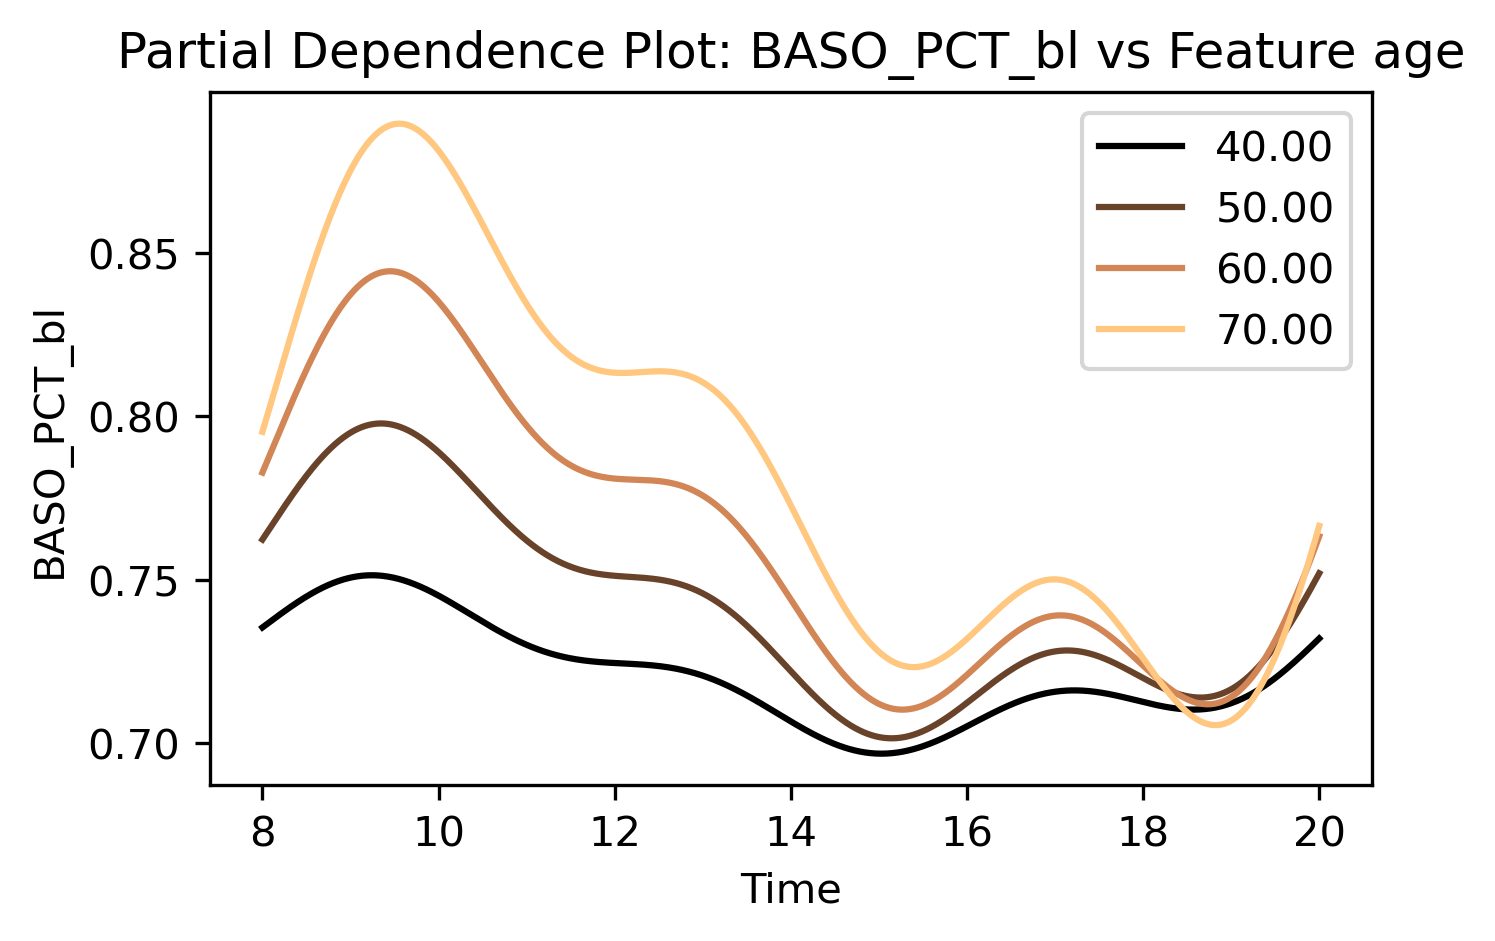

In [17]:
# how to display partial dependence plots in png format inline

Image('./tmp/partial_dependence_age.png', width=400)


## SHAP values

In [18]:
shap_importance = ShapImportance(model.model, X_train_features, X_train_time, y_train, covariates, response, nsamples_background=1000, nsamples=50)

In [19]:
shap_importance.compute_shap()


Initializing SHAP KernelExplainer...
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Computing SHAP values for 50 samples... (This may take a moment)


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step


...

 96%|█████████▌| 48/50 [00:28<00:01,  1.70it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step


 98%|█████████▊| 49/50 [00:28<00:00,  1.70it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 893us/step


100%|██████████| 50/50 [00:29<00:00,  1.70it/s]


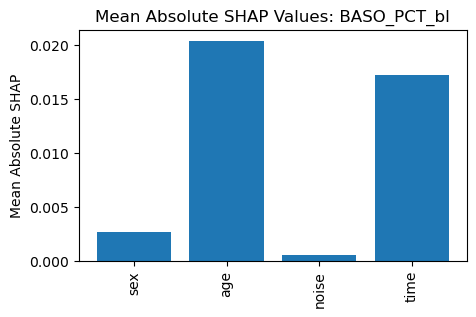

In [22]:
shap_importance.plot_shap_absolute('./tmp/shap_absolute.png')

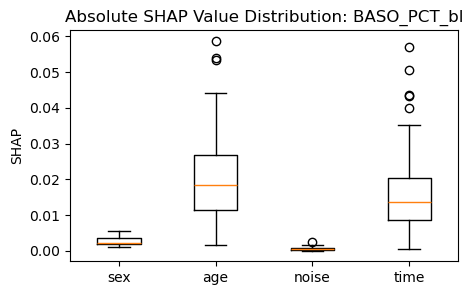

In [33]:
diff_test = shap_importance.plot_shap_boxplots('./tmp/shap_boxplots.png')

In [35]:
diff_test

{'sex': (np.float64(0.0021716584148013234),
  np.float64(2.1707141300277897e-18)),
 'age': (np.float64(0.019877753321727688), np.float64(1.1687878949380995e-13))}

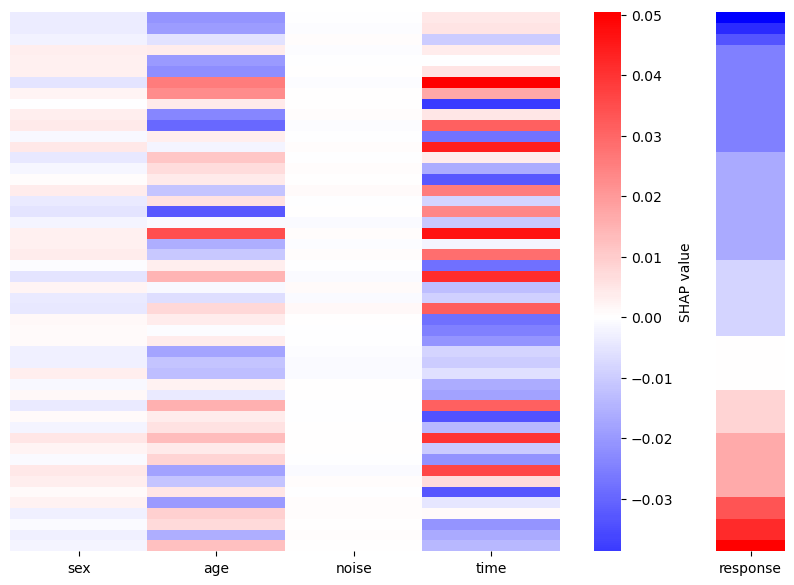

In [112]:
shap_importance.plot_shap_heatmap('./tmp/shap_heatmap.png')

In [36]:
import pickle
with open('./output/FERR_bl/out_summary_FERR_bl.pickle', 'rb') as f:
    d = pickle.load(f)


In [39]:
d

{'input_file': 'output.tsv',
 'response': 'FERR_bl',
 'diff_test': {'sex': (np.float64(11.5195603083801),
   np.float64(3.10070620513016e-70)),
  'age': (np.float64(0.31941478506725746),
   np.float64(2.6812518162316243e-09))},
 'eval_results': [2877.668701171875, 30.94607162475586],
 'shap_values': array([[[-1.08046180e+01],
         [-1.99737966e-01],
         [-1.23317512e-02],
         [ 3.57687350e-01]],
 
        [[ 1.19919698e+01],
         [ 6.86969206e-01],
         [-5.62458061e-02],
         [ 6.29526985e-01]],
 
        [[-1.21156004e+01],
         [ 2.87898359e-01],
         [-3.90391773e-02],
         [-1.65435728e-01]],
 
        [[-1.10692747e+01],
         [-1.24750759e-01],
         [ 3.49559069e-02],
         [ 1.96178951e-01]],
 
        [[ 1.08554532e+01],
         [-6.52465784e-01],
         [ 1.84351708e-02],
         [-6.52464199e-01]],
 
        [[ 1.14649649e+01],
         [ 6.16557952e-01],
         [-8.86213942e-02],
         [-2.65415780e-01]],
 
        [[

# Benchmarks

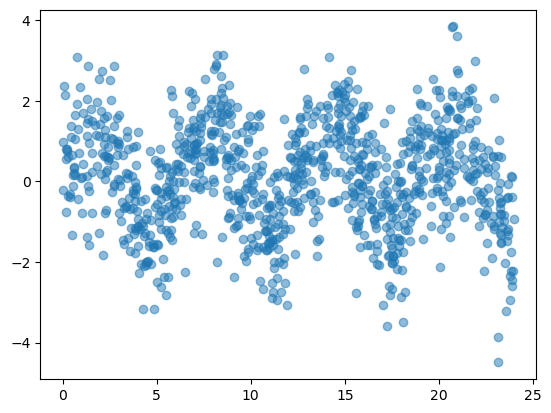

In [107]:
# simulated data 1

sigma = 1.0
n_samples = 1000

sex = np.random.choice([0, 1], size=n_samples)
age = np.random.uniform(20, 70, size=n_samples)
time = np.random.uniform(0, 24, size=n_samples)

# Simulate response variable with a sinusoidal pattern plus noise

y = np.sin(time) + (age / 100) * np.cos((2 + sex) * time) + 0.25 * sex + np.random.normal(0, sigma, size=n_samples)

plt.scatter(time, y, alpha=0.5)
plt.show()

In [108]:
df = pd.DataFrame({
    'sex': sex,
    'age': age,
    'time': time,
    'response': y})
df

,sex,age,time,response
0,1,22.834513,7.102644,1.264610
1,0,36.285000,9.195208,-1.111123
2,1,25.177444,3.830816,-0.482888
3,0,24.636275,8.694851,0.559068
4,0,29.595005,15.842632,0.400970
...,...,...,...,...
995,0,40.125236,7.732719,1.791006
996,0,48.912071,5.144839,0.156241
997,0,27.306168,4.434077,-2.071968
998,1,41.468708,16.112243,0.964472


In [110]:
# Format data

response = 'response'
covariates = ['sex', 'age']
X, y, time_data = preprocess_data(df, covariates, response, scale=False)

# Generate training data

X_train_features, X_test_features, X_train_time, X_test_time, y_train, y_test = generate_training_data(X, y)

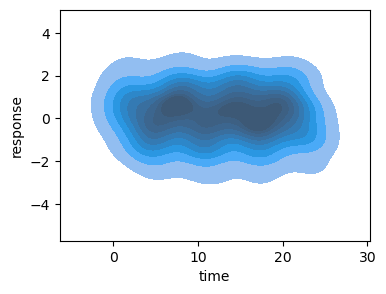

In [111]:
# plot data as a kde density plot

import seaborn as sns

plt.figure(figsize=(4, 3))
sns.kdeplot(
    data=df, x="time", y=response, fill=True,
)
plt.show()

In [ ]:
model = FourierModel(input_dim=X_train_features.shape[1], period=24.0, n_harmonics=3, learning_rate=0.005)

In [ ]:
model.train(X_train_features, X_train_time, y_train, X_test_features, X_test_time, y_test)

In [117]:
plot_partial_dependence_sex(model.model, X, './tmp/partial_dependence_sex.toy.3.png', response)
plot_partial_dependence_age(model.model, './tmp/partial_dependence_age.toy.3.png', response)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


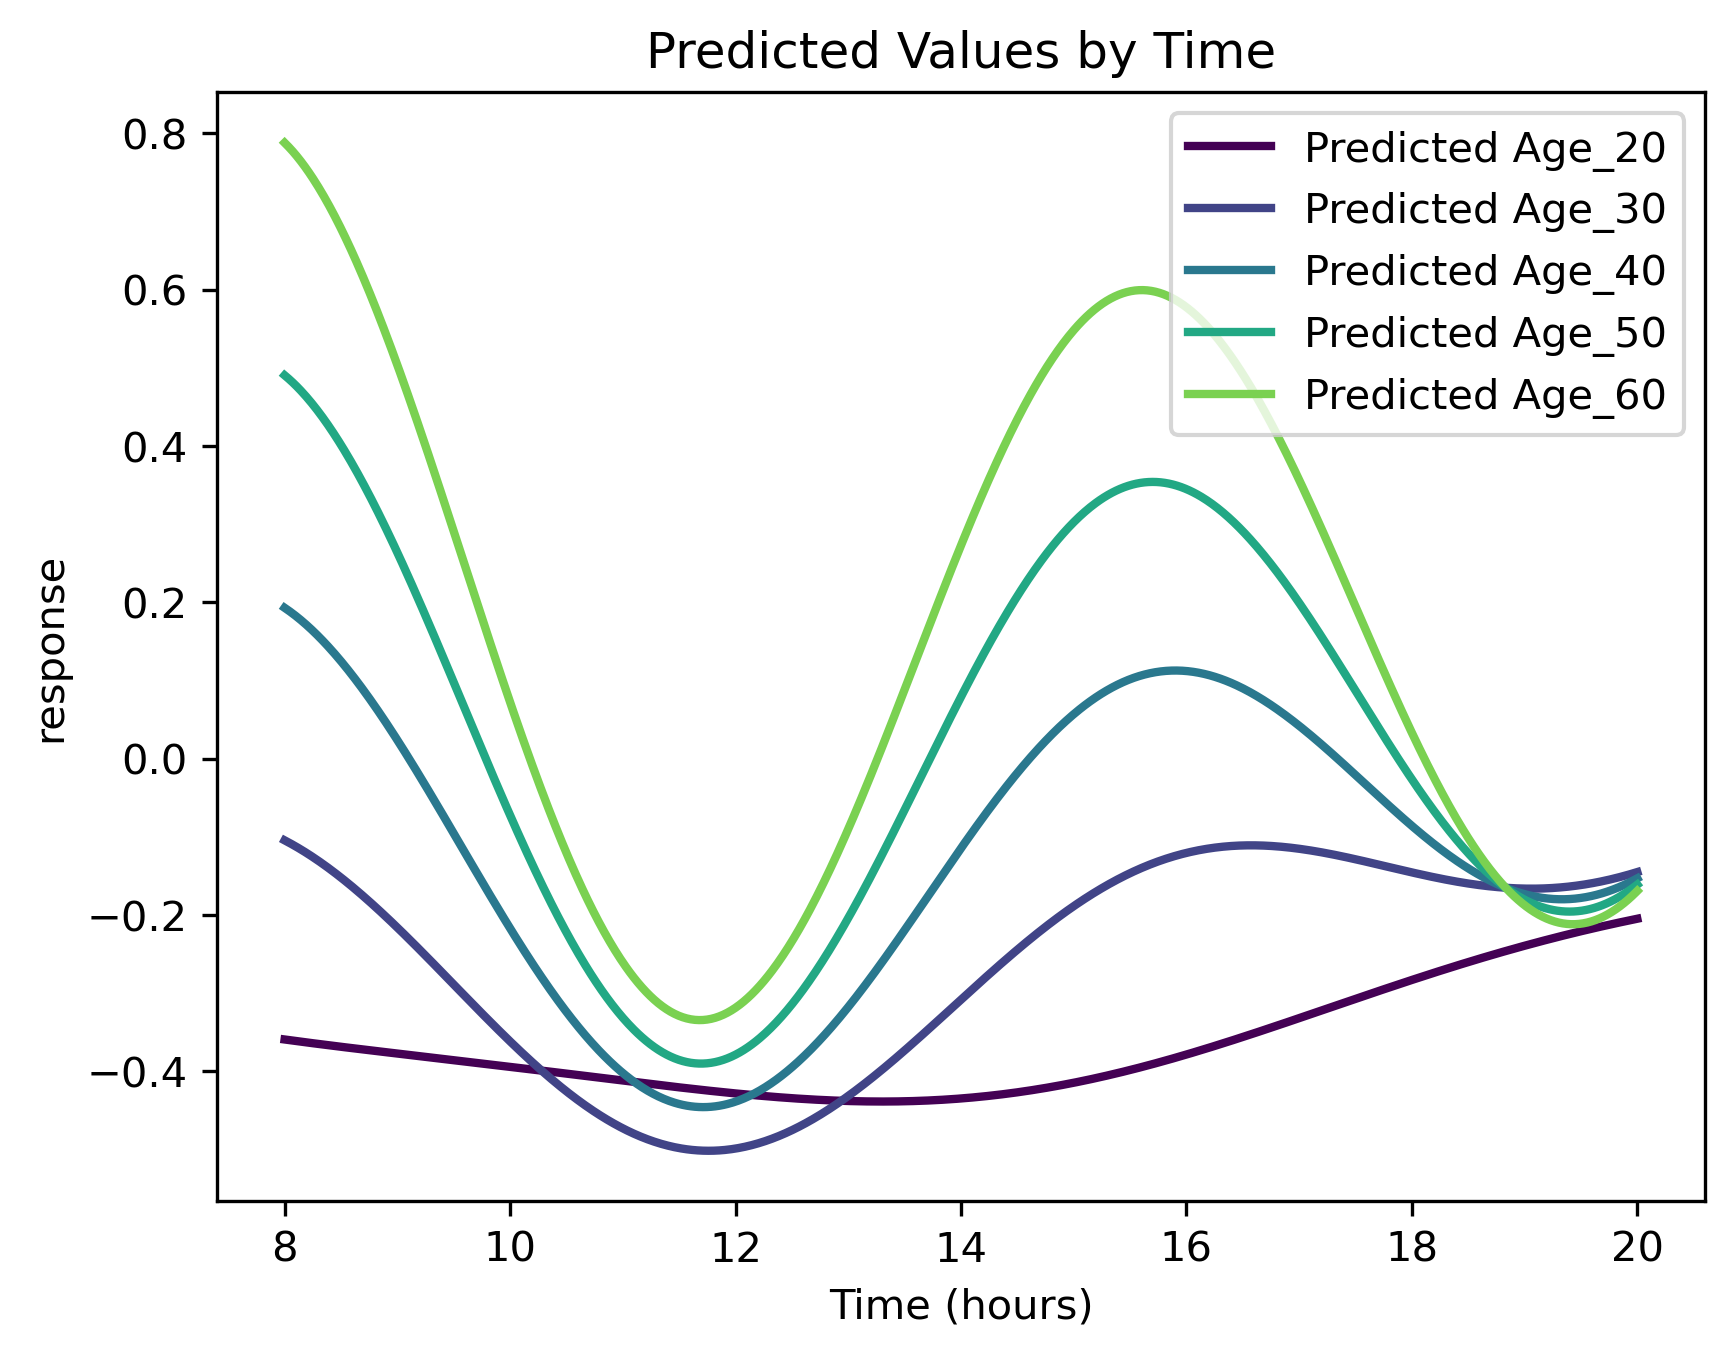

In [120]:
# how to display partial dependence plots in png format inline

Image('./tmp/partial_dependence_age.toy.3.png', width=400)

In [38]:
import shap
from fourier_regression import plot_shap_absolute, plot_shap_heatmap

# SHAP

# Define a wrapper function for the model's prediction
# SHAP KernelExplainer requires a model function that takes a single numpy array
# as input. Since our model takes two inputs, we combine them into a single array
# and then separate them inside this wrapper function.
# The `X` array passed to the wrapper will have shape (num_samples, input_dim + 1).
def model_predict_wrapper(X):
    """
    Wrapper function for the model's prediction.
    It takes a single combined numpy array, separates it into features and time,
    and then calls the model's predict method.
    """
    X_features = X[:, :3]
    X_time = X[:, 3:]

    # Return the model's prediction as a numpy array
    return model.model.predict([X_features, X_time])

X_combined = np.hstack([X_train_features, X_train_time])

# Select a background dataset for the explainer
# A small, representative subset of the training data is typically used.
background = X_combined[np.random.choice(X_combined.shape[0], 100, replace=False)]
print("\nInitializing SHAP KernelExplainer...")
explainer = shap.KernelExplainer(model_predict_wrapper, background)

# Select a random subset of data to explain

num_samples_to_explain = 50
index_selection = np.random.choice(X_combined.shape[0], num_samples_to_explain, replace=False)
X_to_explain = X_combined[index_selection]

# Compute the SHAP values
print(f"Computing SHAP values for {num_samples_to_explain} samples... (This may take a moment)")
shap_values = explainer.shap_values(X_to_explain)

# Plot mean absolute SHAP
plot_shap_absolute(shap_values, covariates + ['time'], './tmp/shap_absolute.toy.3.png')

# Plot SHAP heatmap
plot_shap_heatmap(shap_values, y_train, index_selection, covariates, './tmp/shap_heatmap.toy.3.png')


Initializing SHAP KernelExplainer...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Computing SHAP values for 50 samples... (This may take a moment)


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


  2%|▏         | 1/50 [00:00<00:09,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


...

 96%|█████████▌| 48/50 [00:08<00:00,  5.42it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


 98%|█████████▊| 49/50 [00:08<00:00,  5.42it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


100%|██████████| 50/50 [00:09<00:00,  5.45it/s]


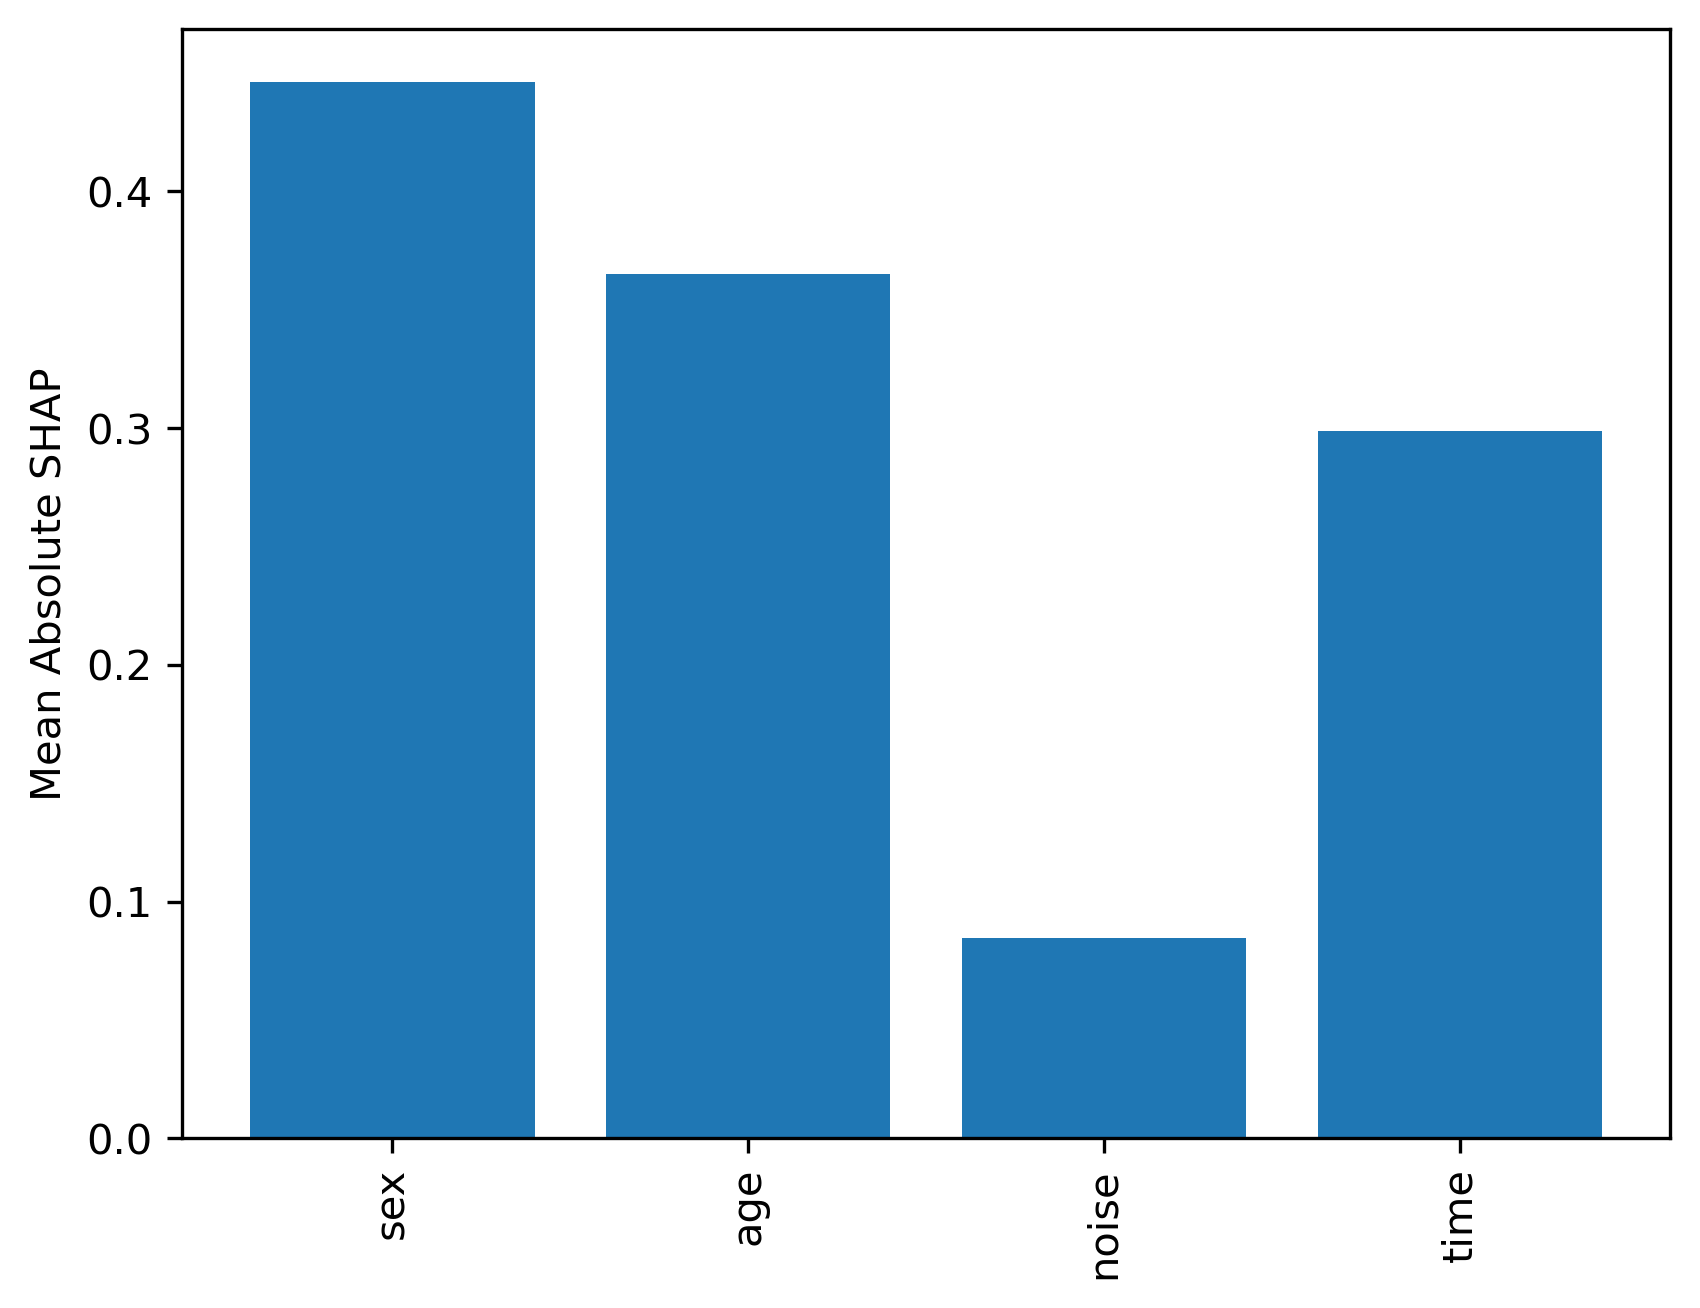

In [39]:
Image('./tmp/shap_absolute.toy.3.png', width=400)

```
Group comparisons can be carried out between feature importances, 
taking all individual local explanations collectively and comparing groups with e.g. Mann-Whitney.
If we include in the model a noise feature that is e.g. white noise, 
completely independent from neither the features nor the responses, 
we can then compare each genuine feature against this "noise" distribution in terms of local feature explanations (e.g. SHAP).
```